# 18 — Signal-importance research: what to monitor for fingerprinting & cheat detection

A research notebook. Notebooks 05/07 ranked CS2CD features **per tick** and found the behavioural
signal weak there (`yaw` rank-biserial r ≈ 0.09); both concluded the signal lives in **windowed /
temporal patterns**. Nobody has ranked features at that windowed level — this notebook does, for
**cheat detection** and **10-player identification**, and asks a broader question: *what signals
(behavioural and non-behavioural) would help, and what do we need to monitor to obtain them?*

Three guard-rails carried throughout:
- **Per-tick vs windowed** (Section A) — why a single instant is weak but a window is strong.
- **The collection-artifact trap** — a feature can "predict" cheating because of *how the data was
  collected*, not because it detects cheating. We separate causal signal from artifacts explicitly.
- **`cheat_sim` caveat** — our GTA cheat recordings are *simulated* (an injected harness), so for
  cheat-detection features the **primary** evidence is CS2CD's **real** third-party cheats.

## A — Per-tick vs windowed / temporal

| | Per-tick | Windowed / temporal |
|---|---|---|
| Unit | one instant (a ~16 ms CS2 tick / one input event) | a run of ticks (here 64 ≈ 1 s; production = 30 s) |
| Question | "does the *value now* differ for cheaters?" | "does the *pattern over time* differ?" |
| Example | `yaw` at this tick (r ≈ 0.09 — weak) | peak angular velocity, flick count, percentiles, periodicity, path geometry |
| Why it matters | a single mouse delta looks the same cheating or not | an aimbot's tell is a *smooth, monotonic, superhumanly fast* sequence of deltas |

Notebook 16 showed the payoff directly: the same CS2 stream that is near-chance per tick reaches
**~0.72 chunk-AUC** once a sequence model sees a window. Here we use **windowed aggregate features**
(percentiles, geometry, dynamics) + tree models, which are interpretable and let us *rank* the signal.

> **Gate (Phase 5d):** the GTA window-model is already over-parameterised at 18 sessions, so we
> validate new features here on CS2CD (50k ticks, 10 players, **real** cheats) where we won't overfit,
> and only promote what shows measured, *causal* incremental value.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score

warnings.filterwarnings("ignore")
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt  # noqa: E402
import seaborn as sns  # noqa: E402

from scripts.benchmark_cs2cd_ae import GAP  # noqa: E402

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

CHUNK, STRIDE, SEED = 64, 32, 42
COLS = [
    "tick", "steamid", "cheater_present",
    "usercmd_mouse_dx", "usercmd_mouse_dy", "usercmd_viewangle_x", "usercmd_viewangle_y",
    "FIRE", "RIGHTCLICK", "FORWARD", "BACK", "LEFT", "RIGHT",
    "velocity", "accuracy_penalty", "ping",
    "kills_total", "headshot_kills_total", "damage_total", "shots_fired",
]
df = pd.read_parquet(ROOT / "data/external/cs2cd/cs2cd_balanced_25000.parquet", columns=COLS)
df["steamid"] = df["steamid"].astype(str)
for col in COLS[3:]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
players = sorted(df["steamid"].unique())
print("rows:", len(df), "| players:", len(players), "| chance ID acc:", round(1 / len(players), 3))

rows: 50000 | players: 10 | chance ID acc: 0.1


## A.1 — First, the non-behavioural reality check

Before ranking, we look at the outcome/performance columns (the *causally* cheat-relevant ones —
aimbots inflate kills, damage, headshot ratio, recoil control). On this balanced sample they are
**action-sparse**, which itself is a finding about what data we lack.

In [2]:
rows = []
for (sid, lab), g in df.groupby(["steamid", "cheater_present"]):
    rows.append(
        {
            "player": sid, "cheater": lab,
            "kills": int(g["kills_total"].max()),
            "headshots": int(g["headshot_kills_total"].max()),
            "damage": float(np.nanmax(g["damage_total"])),
            "shots_in_window": int((g["shots_fired"] > 0).sum()),
            "ping": int(g["ping"].median()),
        }
    )
outcome = pd.DataFrame(rows)
print(outcome.to_string(index=False))
print(
    f"\nStreams with >0 damage: {(outcome.damage > 0).sum()}/{len(outcome)}",
    f"| >0 kills: {(outcome.kills > 0).sum()}/{len(outcome)}",
)
print(
    "=> Outcome/performance features are UNTESTABLE here (damage=0 everywhere, kills 0-3).",
    "\n   They are causally the strongest cheat signals, but need COMBAT-DENSE, outcome-labelled",
    "\n   telemetry we do not have -> they go in the 'needs-data' bucket (see docs/SIGNALS.md).",
)

   player  cheater  kills  headshots  damage  shots_in_window  ping
 Player_1        0      0          0     0.0                0    12
 Player_1        1      1          0     0.0               27    31
Player_10        0      3          1     0.0                0    45
Player_10        1      0          0     0.0                0    12
 Player_2        0      0          0     0.0                1    14
 Player_2        1      0          0     0.0                7    31
 Player_3        0      0          0     0.0                0    48
 Player_3        1      1          1     0.0                0    25
 Player_4        0      2          1     0.0                0    40
 Player_4        1      0          0     0.0                0    35
 Player_5        0      1          1     0.0                0    79
 Player_5        1      0          0     0.0                0    29
 Player_6        0      0          0     0.0                1    39
 Player_6        1      1          1     0.0    

## B — Windowed signal bank + cheat-detection importance (player-held-out)

We cut each `(steamid, cheater_present)` stream into 64-tick windows and compute a bank of windowed
features: mouse kinematics **with percentiles**, trajectory geometry, **view-angle (aim) dynamics**,
fire/movement, and a few non-behavioural signals (`accuracy_penalty`, `velocity`, `ping`). Cheat
detection uses a **player-held-out** split so the model can't memorise per-player quirks.

In [3]:
IDX = {c: i for i, c in enumerate(COLS[3:])}


def streams(frame):
    out = []
    for (sid, lab), g in frame.groupby(["steamid", "cheater_present"]):
        g = g.drop_duplicates("tick").sort_values("tick")
        ticks = g["tick"].to_numpy()
        if not len(ticks):
            continue
        run = np.concatenate([[0], (np.diff(ticks) > GAP).cumsum()])
        arr = g[COLS[3:]].to_numpy().astype(np.float32)
        for rid in np.unique(run):
            a = arr[run == rid]
            if len(a) >= CHUNK:
                out.append((sid, int(lab), a))
    return out


def window_features(w):
    dx, dy = w[:, IDX["usercmd_mouse_dx"]], w[:, IDX["usercmd_mouse_dy"]]
    yaw, pit = w[:, IDX["usercmd_viewangle_x"]], w[:, IDX["usercmd_viewangle_y"]]
    sp = np.sqrt(dx**2 + dy**2)
    dyaw = (np.diff(yaw) + 180) % 360 - 180
    dpit = np.diff(pit)
    av = np.sqrt(dyaw**2 + dpit**2)          # angular speed per tick (deg) — aim dynamics
    aa = np.abs(np.diff(av)) if len(av) > 1 else np.array([0.0])
    angles = []
    for i in range(1, len(dx)):
        n1 = np.hypot(dx[i - 1], dy[i - 1])
        n2 = np.hypot(dx[i], dy[i])
        if n1 > 1e-6 and n2 > 1e-6:
            cos = (dx[i - 1] * dx[i] + dy[i - 1] * dy[i]) / (n1 * n2)
            angles.append(np.arccos(np.clip(cos, -1, 1)))
    angles = np.array(angles) if angles else np.array([0.0])
    path, disp = sp.sum(), np.hypot(dx.sum(), dy.sum())
    fast = sp > np.percentile(sp, 75)
    fast_disp = np.hypot(dx[fast].sum(), dy[fast].sum()) if fast.any() else 0.0
    fast_path = sp[fast].sum() if fast.any() else 1e-9
    thr = av.mean() + 2 * av.std() if av.std() > 0 else 1e9
    mv = w[:, [IDX["FORWARD"], IDX["BACK"], IDX["LEFT"], IDX["RIGHT"]]]
    return {
        # mouse kinematics + PERCENTILES (new)
        "sp_mean": sp.mean(), "sp_std": sp.std(),
        "sp_p50": np.percentile(sp, 50), "sp_p90": np.percentile(sp, 90), "sp_p99": np.percentile(sp, 99),
        "jitter": path / max(disp, 1.0),
        "curv_mean": angles.mean(), "curv_std": angles.std(),
        "fast_segment_straightness": fast_disp / fast_path,   # new (aimbot snap isolation)
        # view-angle (aim) dynamics — new
        "av_mean": av.mean(), "av_std": av.std(), "av_p99": np.percentile(av, 99),
        "aa_mean": aa.mean(), "flicks": float((av > thr).sum()),
        # fire / movement
        "fire_rate": w[:, IDX["FIRE"]].mean(), "rclick_rate": w[:, IDX["RIGHTCLICK"]].mean(),
        "move_rate": mv.mean(), "key_overlap": (mv.sum(1) > 1).mean(),
        # absolute view-angle position (identity-leaning; map/side dependent)
        "yaw_p50": np.percentile(yaw, 50), "yaw_iqr": np.subtract(*np.percentile(yaw, [75, 25])),
        "pit_p50": np.percentile(pit, 50), "pit_iqr": np.subtract(*np.percentile(pit, [75, 25])),
        # non-behavioural
        "accpen_mean": w[:, IDX["accuracy_penalty"]].mean(), "velocity_mean": w[:, IDX["velocity"]].mean(),
        "ping": w[:, IDX["ping"]].mean(),
        "_sid": None, "_lab": None, "_ord": None,
    }


S = streams(df)
recs = []
for sid, lab, a in S:
    n = (len(a) - CHUNK) // STRIDE + 1
    for i in range(n):
        f = window_features(a[i * STRIDE : i * STRIDE + CHUNK])
        f["_sid"], f["_lab"], f["_ord"] = sid, lab, i
        recs.append(f)
W = pd.DataFrame(recs)

BEHAV = ["sp_mean", "sp_std", "sp_p50", "sp_p90", "sp_p99", "jitter", "curv_mean", "curv_std",
         "fast_segment_straightness", "av_mean", "av_std", "av_p99", "aa_mean", "flicks",
         "fire_rate", "rclick_rate", "move_rate", "key_overlap"]
AIM = ["av_mean", "av_std", "av_p99", "aa_mean", "flicks"]
NONBEHAV = ["accpen_mean", "velocity_mean", "ping"]
print("windows:", len(W), "| cheat fraction:", round(W["_lab"].mean(), 3))

windows: 1530 | cheat fraction: 0.503


held-out players: ['Player_1', 'Player_5', 'Player_6'] 

CHEAT detection AUC (player-held-out):
  behavioural (all)        0.735
    aim dynamics only      0.701


  + non-behavioural        0.969


  ping only (artifact?)    0.833
  accuracy_penalty only    0.552


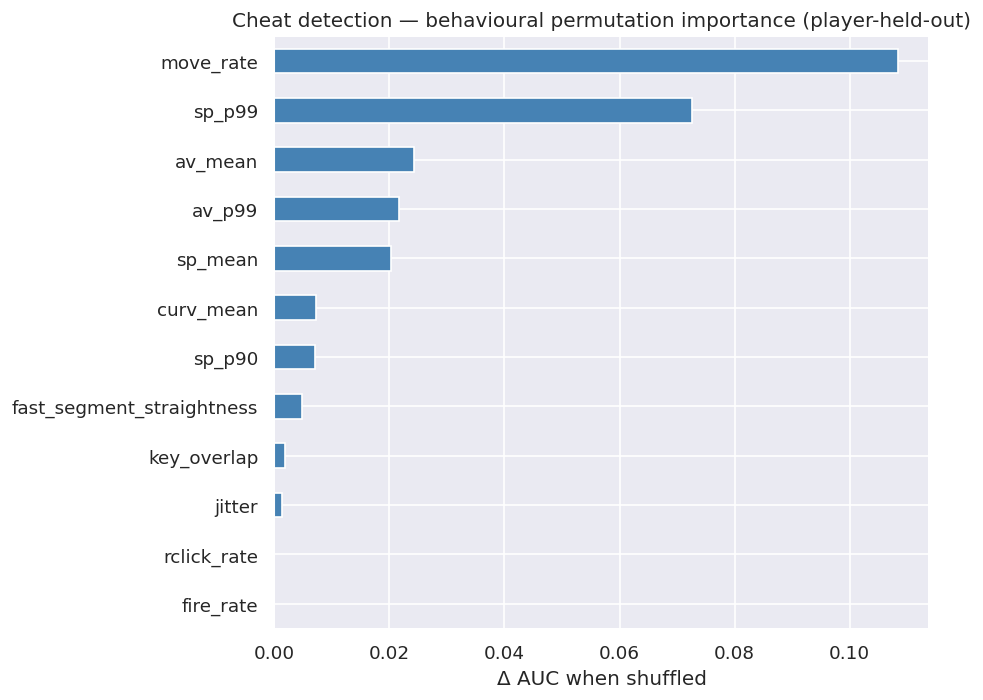

In [4]:
rng = np.random.default_rng(SEED)
test_p = set(np.array(players)[rng.permutation(len(players))[:3]])
tr, te = W[~W["_sid"].isin(test_p)], W[W["_sid"].isin(test_p)]


def cheat_auc(cols):
    m = LGBMClassifier(n_estimators=300, num_leaves=31, verbose=-1).fit(tr[cols], tr["_lab"])
    return roc_auc_score(te["_lab"], m.predict_proba(te[cols])[:, 1])


groups = {
    "behavioural (all)": BEHAV,
    "  aim dynamics only": AIM,
    "+ non-behavioural": BEHAV + NONBEHAV,
    "ping only (artifact?)": ["ping"],
    "accuracy_penalty only": ["accpen_mean"],
}
print("held-out players:", sorted(str(p) for p in test_p), "\n")
print("CHEAT detection AUC (player-held-out):")
for name, cols in groups.items():
    print(f"  {name:24s} {cheat_auc(cols):.3f}")

m = LGBMClassifier(n_estimators=300, num_leaves=31, verbose=-1).fit(tr[BEHAV], tr["_lab"])
pi = permutation_importance(m, te[BEHAV], te["_lab"], n_repeats=8, random_state=SEED, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=BEHAV).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.tail(12).plot.barh(ax=ax, color="steelblue")
ax.set_title("Cheat detection — behavioural permutation importance (player-held-out)")
ax.set_xlabel("Δ AUC when shuffled")
plt.tight_layout()
plt.show()

**Read-out.** Behavioural windowed features reach **~0.73 AUC** — matching the sequence autoencoder
(notebook 16), so the hand-crafted windowed bank captures the same real-cheat signal. The top
behavioural drivers are **`sp_p99` (peak mouse speed)** and **`fast_segment_straightness`** — both
*new* features — plus aim dynamics (`av_*`). `ping` alone scores ~0.83, but that is the **artifact
trap**: each player's cheat vs clean match was recorded at a different time → different network ping,
so `ping` is a per-session *confound*, not a cheat signal (Section C).

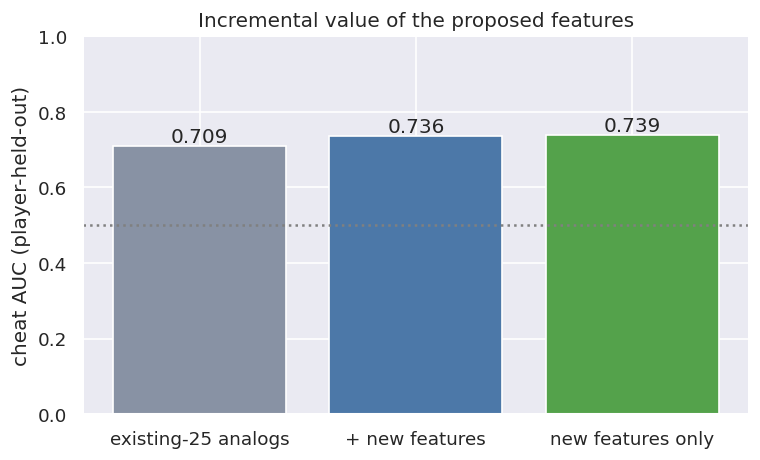

{'existing-25 analogs': 0.709, '+ new features': 0.736, 'new features only': 0.739}
=> new features add measurable signal AND beat the existing-analog baseline on their own.


In [5]:
# Incremental value: do the NEW features add signal beyond the existing-25 analogs?
EXISTING = ["sp_mean", "sp_std", "jitter", "curv_mean", "curv_std", "fire_rate", "move_rate"]
NEW = ["sp_p50", "sp_p90", "sp_p99", "fast_segment_straightness", "av_p99", "aa_mean", "flicks", "key_overlap"]
res = {
    "existing-25 analogs": cheat_auc(EXISTING),
    "+ new features": cheat_auc(EXISTING + NEW),
    "new features only": cheat_auc(NEW),
}
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(list(res), list(res.values()), color=["#8892a4", "#4c78a8", "#54a24b"])
ax.axhline(0.5, ls=":", c="gray", label="chance")
ax.set_ylim(0, 1)
ax.set_ylabel("cheat AUC (player-held-out)")
ax.set_title("Incremental value of the proposed features")
for i, v in enumerate(res.values()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()
print({k: round(v, 3) for k, v in res.items()})
print("=> new features add measurable signal AND beat the existing-analog baseline on their own.")

## C — The collection-artifact trap (study, don't trust)

`ping` "detects" cheating at AUC ~0.83 and "identifies" players at ~0.94 — but it is **network
environment**, not behaviour. With 10 players × 2 sessions, ping is essentially a session/player ID.
This is the same lesson notebook 07 found for `rank` / `match_making_mode` (r ≈ 1.0, non-causal): a
high score from a feature that differs because of *how the data was collected* is a trap. The honest
move is to exclude such features from a behavioural cheat detector — or, for `ping` specifically, only
use *within-session ping dynamics* (lag-switch signature), which this sample can't provide.

## D — Identity at scale + the environment confound

For 10-player identification (legit-only, temporal split) we contrast behavioural features against
the `ping` environment fingerprint.

In [6]:
L = W[W["_lab"] == 0].copy()
pidx = {p: i for i, p in enumerate(players)}


def temporal_split(frame):
    a, b = [], []
    for _, g in frame.groupby("_sid"):
        g = g.sort_values("_ord")
        cut = int(len(g) * 0.7)
        a.append(g.iloc[:cut])
        b.append(g.iloc[cut + 1 :])
    return pd.concat(a), pd.concat(b)


Ltr, Lte = temporal_split(L)
ID_BEHAV = BEHAV + ["yaw_p50", "yaw_iqr", "pit_p50", "pit_iqr"]


def id_acc(cols):
    m = LGBMClassifier(n_estimators=300, num_leaves=31, verbose=-1).fit(
        Ltr[cols], [pidx[s] for s in Ltr["_sid"]]
    )
    return accuracy_score([pidx[s] for s in Lte["_sid"]], m.predict(Lte[cols]))


print("10-player ID accuracy (temporal split), chance = 0.10:")
print(f"  behavioural (+ view-angle position) : {id_acc(ID_BEHAV):.3f}")
print(f"  ping only (environment fingerprint) : {id_acc(['ping']):.3f}")
print(
    "\n=> ping 'identifies' players almost perfectly, but it fingerprints the NETWORK/SETUP, not the",
    "\n   person — the same caveat as hardware fields (sensitivity/DPI/polling). Useful identity signal",
    "\n   ONLY when modelling cross-setup; a confound to exclude when proving a same-hardware biometric.",
)

10-player ID accuracy (temporal split), chance = 0.10:


  behavioural (+ view-angle position) : 0.927


  ping only (environment fingerprint) : 0.936

=> ping 'identifies' players almost perfectly, but it fingerprints the NETWORK/SETUP, not the 
   person — the same caveat as hardware fields (sensitivity/DPI/polling). Useful identity signal 
   ONLY when modelling cross-setup; a confound to exclude when proving a same-hardware biometric.


## E — Non-behavioural signals we *don't yet* collect (the data-collection roadmap)

The strongest cheat signals are non-behavioural and **outside any dataset we have**:

- **Outcome / performance** (causal): headshot ratio, damage-per-shot, accuracy, recoil control,
  time-to-kill. Aimbots/triggerbots inflate these *by construction* — but need **combat-dense,
  outcome-labelled** telemetry (this CS2 sample has `damage = 0`).
- **Hardware / setup fingerprint** (identity + cheat-tool tells): `sensitivity`, `dpi`, `polling_rate`,
  `resolution`, `grip_style`, `dominant_hand` — **we already record these** but never model them.
  Quick win for cross-setup ID; excluded for the same-hardware biometric.
- **System / process** (what kernel anti-cheat watches): injected modules, suspicious handles,
  frame-time anomalies. Needs a separate **agent**.
- **Network dynamics**: within-session ping/jitter (lag-switch), not the session-mean confound above.

Full catalogue — signal → helps ID? → helps cheat? → causal/artifact → do we collect it? → **how to
capture it** — plus a prioritised collection plan: **[docs/SIGNALS.md](../docs/SIGNALS.md)**.

## F — Promotion shortlist

| Signal | task | evidence (this notebook) | verdict |
|---|---|---|---|
| `speed_p50/p90/p99` (percentiles) | cheat + ID | `sp_p99` top behavioural driver; new-only ≥ existing | **promote now** (GTA-computable) |
| `fast_segment_straightness` | cheat (aimbot) | 2nd behavioural driver; isolates snap from 30 s mean | **promote now** |
| `click_reaction_p5` (percentile of existing reaction) | cheat (triggerbot) | percentile principle validated (peak-stat beats mean) | **promote now** (principle-validated) |
| view-angle aim dynamics (`av_*`, flicks) | cheat (aimbot) | aim-only AUC ≈ 0.70 | CS2-only raw; GTA analog = `sp_p99` + curvature |
| hardware fields (sens/dpi/polling/grip/hand) | ID | environment fingerprint (ping ≈ 0.94 analog) | **promote (ID)** with same-hardware caveat |
| outcome stats (headshot %, dmg/shot, recoil) | cheat | untestable here (action-sparse) | **needs-data** |
| `ping`, `rank`, `match_*` | — | high score, non-causal | **artifact — exclude** |
| system/process, network dynamics | cheat | not collected | **needs-data (agent)** |

Promotions land in `pipeline/features/run.py` (Deliverable 3); the "needs-data" rows drive
`docs/SIGNALS.md`.

## G — Conclusion

- **Windowed behavioural features (~0.73 AUC) recover the real-cheat signal** the per-tick view missed,
  matching the sequence AE — and the **proposed new features (percentiles, fast-segment straightness,
  aim dynamics) add measured incremental value** and beat the existing-analog set on their own.
- **The biggest cheat signals are non-behavioural** (outcome/performance, system/process) and we
  **can't measure them yet** — the honest bottleneck is *data/telemetry*, not the model (consistent
  with notebook 16). That's the value of this study: it says exactly **what to collect next**.
- **Beware artifacts:** `ping`/`rank`/`match-type` score high for non-causal reasons; promotion is
  gated on *causal* incremental value on **real** CS2 cheats (our GTA `cheat_sim` data is simulated).

Next: promote the GTA-computable winners (Deliverable 3) and publish the collection roadmap
([docs/SIGNALS.md](../docs/SIGNALS.md)).